
# 1. Loading the dataset

In [3]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
uploaded = files.upload()
df = pd.read_csv("package.csv")

Saving package.csv to package.csv


# 2. Renaming columns for cleaner access and Handling Categorical Data (Sorting them logically)

In [13]:



column_mapping = {
    'How many days per week do you engage in physical activity?': 'Exercise',
    'On average, how would you rate your daily energy level? ': 'Energy',
    'On average, how would you rate your concentration while studying?': 'Focus',
    'On average, how many hours do you sleep per night': 'Sleep',
    'How many hours per day do you spend using your phone?': 'Phone',
    'How many hours do you study per day?': 'Study'
}
df = df.rename(columns=column_mapping)


exercise_order = ['0', '1-2', '3-4', '5+']
phone_order = ['less than 2', '2-4', '4-6', '6+']
study_order = ['less than 1 hr', '1-2 hrs', '3-4 hrs', '5-6 hrs', '6+ hrs']

df['Exercise'] = pd.Categorical(df['Exercise'], categories=exercise_order, ordered=True)
df['Phone'] = pd.Categorical(df['Phone'], categories=phone_order, ordered=True)
df['Study'] = pd.Categorical(df['Study'], categories=study_order, ordered=True)





# 3. Calculating descriptive analysis

In [16]:
numerical_stats = df[['Energy', 'Focus']].agg(['mean', 'median']).round(2)
modes = df[['Exercise', 'Energy', 'Focus', 'Sleep', 'Phone', 'Study']].mode().iloc[0]
print("--- DESCRIPTIVE STATISTICS ---")
print("\nNumerical Stats (Mean & Median):")
print(numerical_stats)
print("\nModes (Most Frequent Responses):")
print(modes)

--- DESCRIPTIVE STATISTICS ---

Numerical Stats (Mean & Median):
        Energy  Focus
mean      5.79   5.56
median    6.00   6.00

Modes (Most Frequent Responses):
Exercise        1-2
Energy          7.0
Focus           6.0
Sleep           6-7
Phone           4-6
Study       1-2 hrs
Name: 0, dtype: object


# 4. Visual representations

Visualization 1: Energy Distribution with Mean/Median line

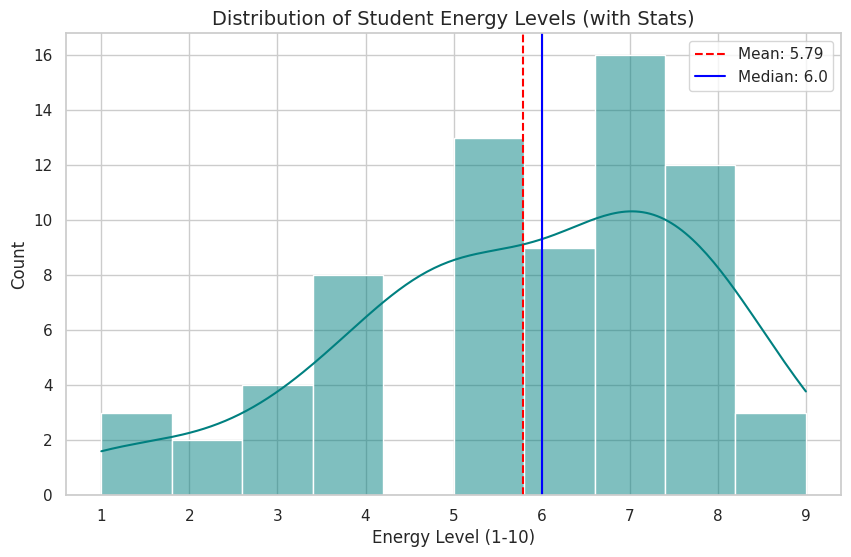

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy'], bins=10, kde=True, color='teal')
plt.axvline(numerical_stats.loc['mean', 'Energy'], color='red', linestyle='--',
            label=f"Mean: {numerical_stats.loc['mean', 'Energy']}")
plt.axvline(numerical_stats.loc['median', 'Energy'], color='blue', linestyle='-',
            label=f"Median: {numerical_stats.loc['median', 'Energy']}")
plt.title('Distribution of Student Energy Levels (with Stats)', fontsize=14)
plt.xlabel('Energy Level (1-10)')
plt.legend()
plt.savefig('energy_distribution.png')



 Visualization 2: Phone Usage vs Average Focus

/tmp/ipykernel_1118/2935630672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Phone', y='Focus', data=df, order=phone_order, palette='mako', errorbar=None)


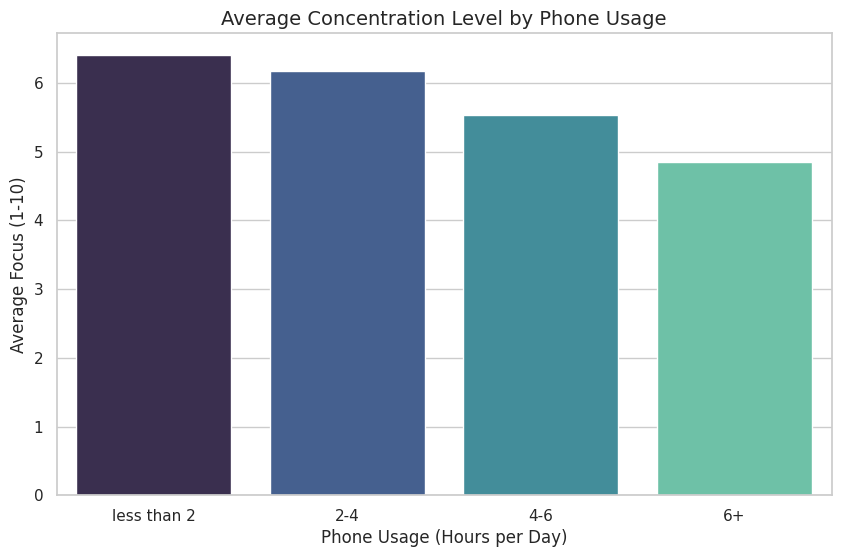

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Phone', y='Focus', data=df, order=phone_order, palette='mako', errorbar=None)
plt.title('Average Concentration Level by Phone Usage', fontsize=14)
plt.xlabel('Phone Usage (Hours per Day)')
plt.ylabel('Average Focus (1-10)')
plt.savefig('phone_focus_trend.png')

 Visualization 3: Study Time Breakdown

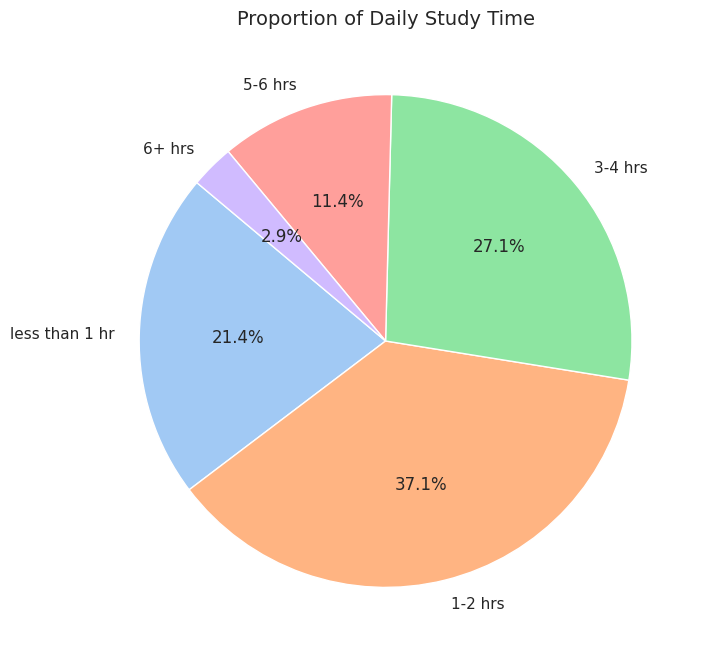

In [18]:
plt.figure(figsize=(8, 8))
study_counts = df['Study'].value_counts().reindex(study_order)
plt.pie(study_counts, labels=study_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Daily Study Time', fontsize=14)
plt.savefig('study_proportion.png')



In [12]:
# Save final cleaned dataset
df.to_csv('final_analyzed_data.csv', index=False)